In [9]:
import sys
print(f"Python version: {sys.version}")
assert sys.version_info >= (3, 8), "Please upgrade to Python 3.8+"
print("✅ Python version OK")

Python version: 3.11.15 (main, Mar  3 2026, 00:52:57) [Clang 17.0.0 (clang-1700.6.3.2)]
✅ Python version OK


In [10]:
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt
import cv2
import os
import shutil
import random

print("✅ TensorFlow:", tf.__version__)
print("✅ NumPy:", np.__version__)
print("✅ OpenCV:", cv2.__version__)
print("✅ All libraries imported successfully!")

✅ TensorFlow: 2.16.2
✅ NumPy: 1.26.4
✅ OpenCV: 4.11.0
✅ All libraries imported successfully!


In [11]:
folders = ["data/raw", "data/train", "data/val", "model", "app"]
for folder in folders:
    if os.path.exists(folder):
        print(f"✅ {folder}")
    else:
        print(f"❌ {folder} — missing! Run mkdir to create it")

✅ data/raw
✅ data/train
✅ data/val
✅ model
✅ app


In [12]:
CATEGORY_MAP = {
    "battery":      "battery",
    "biological":   "biological",
    "brown-glass":  "brown-glass",
    "cardboard":    "cardboard",
    "clothes":      "clothes",
    "green-glass":  "green-glass",
    "metal":        "metal",
    "paper":        "paper",
    "plastic":      "plastic",
    "shoes":        "shoes",
    "trash":        "trash",
    "white-glass":  "white-glass",
}

RAW_DIR = "data/garbage_classification"
VAL_SPLIT = 0.2
MAX_PER_CLASS = 800  # caps imbalanced classes (e.g. clothes has 5000+)

# ── Clean old splits ──
for split in ["train", "val"]:
    split_path = os.path.join("data", split)
    if os.path.exists(split_path):
        shutil.rmtree(split_path)
        print(f"🗑️  Cleared old data/{split}/")

# ── Sort images into train/val ──
for kaggle_cat, our_class in CATEGORY_MAP.items():
    src_folder = os.path.join(RAW_DIR, kaggle_cat)
    if not os.path.exists(src_folder):
        print(f"⚠️  Skipping '{kaggle_cat}' — folder not found")
        continue

    images = [
        f for f in os.listdir(src_folder)
        if f.lower().endswith((".jpg", ".jpeg", ".png"))
    ]
    random.shuffle(images)
    images = images[:MAX_PER_CLASS]          # cap before splitting
    split_idx = int(len(images) * (1 - VAL_SPLIT))

    for split_name, file_list in [("train", images[:split_idx]), ("val", images[split_idx:])]:
        dest = os.path.join("data", split_name, our_class)
        os.makedirs(dest, exist_ok=True)
        for f in file_list:
            shutil.copy(os.path.join(src_folder, f), os.path.join(dest, f))

    print(f"✅ '{kaggle_cat}' → {our_class}  ({split_idx} train / {len(images) - split_idx} val)")

print("\n🎉 Sorting complete!")

🗑️  Cleared old data/train/
🗑️  Cleared old data/val/
✅ 'battery' → battery  (640 train / 160 val)
✅ 'biological' → biological  (640 train / 160 val)
✅ 'brown-glass' → brown-glass  (485 train / 122 val)
✅ 'cardboard' → cardboard  (640 train / 160 val)
✅ 'clothes' → clothes  (640 train / 160 val)
✅ 'green-glass' → green-glass  (503 train / 126 val)
✅ 'metal' → metal  (615 train / 154 val)
✅ 'paper' → paper  (640 train / 160 val)
✅ 'plastic' → plastic  (640 train / 160 val)
✅ 'shoes' → shoes  (640 train / 160 val)
✅ 'trash' → trash  (557 train / 140 val)
✅ 'white-glass' → white-glass  (620 train / 155 val)

🎉 Sorting complete!


In [13]:
for split in ["train", "val"]:
    print(f"\n📁 data/{split}/")
    for cls in sorted(os.listdir(f"data/{split}")):
        path = f"data/{split}/{cls}"
        if os.path.isdir(path):
            count = len(os.listdir(path))
            print(f"  {cls}: {count} images")


📁 data/train/
  battery: 640 images
  biological: 640 images
  brown-glass: 485 images
  cardboard: 640 images
  clothes: 640 images
  green-glass: 503 images
  metal: 615 images
  paper: 640 images
  plastic: 640 images
  shoes: 640 images
  trash: 557 images
  white-glass: 620 images

📁 data/val/
  battery: 160 images
  biological: 160 images
  brown-glass: 122 images
  cardboard: 160 images
  clothes: 160 images
  green-glass: 126 images
  metal: 154 images
  paper: 160 images
  plastic: 160 images
  shoes: 160 images
  trash: 140 images
  white-glass: 155 images


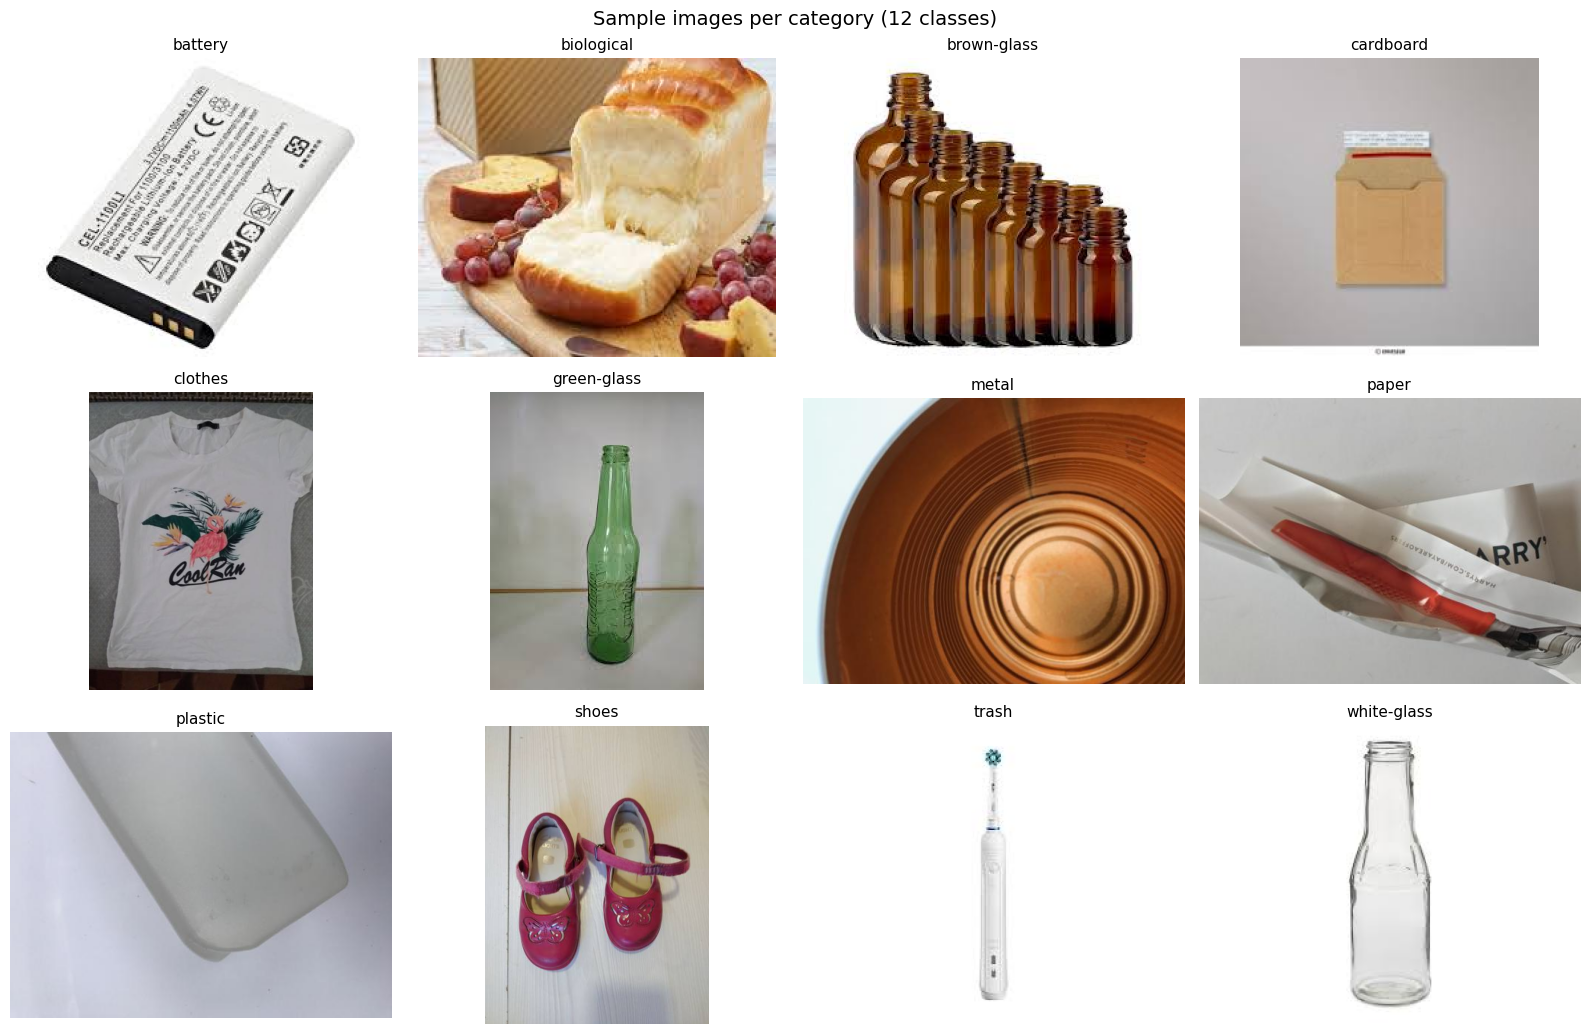

In [14]:
classes = sorted([
    c for c in os.listdir("data/train")
    if os.path.isdir(f"data/train/{c}")
])
n = len(classes)  # 12
cols = 4
rows = (n + cols - 1) // cols  # 3

fig, axes = plt.subplots(rows, cols, figsize=(cols * 4, rows * 3.5))
axes = axes.flatten()

for i, cls in enumerate(classes):
    folder = f"data/train/{cls}"
    sample = os.path.join(folder, os.listdir(folder)[0])
    img = plt.imread(sample)
    axes[i].imshow(img)
    axes[i].set_title(cls, fontsize=11)
    axes[i].axis("off")

# hide unused subplots
for j in range(n, len(axes)):
    axes[j].set_visible(False)

plt.suptitle("Sample images per category (12 classes)", fontsize=14)
plt.tight_layout()
plt.show()